# Titanic Survival Prediction — Model Training & Comparison

This notebook trains and compares multiple classification models to predict
Titanic passenger survival, using the preprocessed data from `src/preprocessing.py`.

**Goal:** train several models, compare their performance using cross-validation,
and identify the strongest candidate(s) for further tuning.

**Baseline to beat:** 61.6% accuracy (always predicting "did not survive").

In [1]:
import sys
sys.path.append('../src')
from preprocessing import full_pipeline

X_train, X_val, y_train, y_val = full_pipeline('../data/train.csv')
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(712, 14) (179, 14) (712,) (179,)


In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
predictions = model.predict(X_val)

In [3]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_val, predictions)
print(accuracy)

0.8156424581005587


In [4]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coefficients)

              Feature  Coefficient
8              Master     2.408691
3         Sex_encoded     2.158674
10                Mrs     1.515419
13           HasCabin     0.577723
9                Miss     0.435669
6                   C     0.416222
7                   Q     0.263078
11               Rare     0.187106
12               Fare     0.003521
4          Age_filled    -0.017176
5   Age_Group_encoded    -0.161133
2             isAlone    -0.269028
1          FamilySize    -0.466629
0              Pclass    -0.656286


In [5]:
from sklearn.model_selection import cross_val_score

lr_cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print(lr_cv_scores)
print(lr_cv_scores.mean())

[0.84615385 0.84615385 0.83098592 0.78873239 0.83098592]
0.8286023835319609


# Logistic Regression

**What it is:** Despite the name, Logistic Regression is a *classification* model (predicts categories), not a regression model that predicts continuous numbers.

**How it works:**
1. Each feature (Pclass, Sex_encoded, Fare, etc.) is multiplied by a learned weight, and all these weighted features are summed together (plus an intercept) — producing a "raw score" that can be any number, positive or negative.
2. That raw score is passed through the **sigmoid function**, an S-shaped curve that squishes any input into a probability between 0 and 1:
   - Large positive raw score → probability close to 1 (likely survived)
   - Large negative raw score → probability close to 0 (likely did not survive)
   - Raw score of 0 → probability of exactly 0.5 (model is unsure)
3. If the resulting probability is above 0.5, the model predicts "survived" (1); otherwise, "did not survive" (0)

**Why it's a good baseline model:**
- Simple and fast to train
- Interpretable — the learned weights show which features push predictions toward survival vs. death, and by how much
- Gives a solid reference point to compare more complex models against later

**Training results:**
- `LogisticRegression(max_iter=1000)` — increased `max_iter` from the default 100 to resolve a convergence warning, likely caused by features being on very different scales (e.g., Fare ranges ~0-500, Sex_encoded is only 0 or 1)
- **Validation accuracy: 81.6%** — a strong improvement over the 61.6% baseline (always predicting "did not survive"); the accuracy means the model correctly predicted survived/death for about 81.6% of the 179 validation passengers
- Note: this accuracy comes from a single train/validation split (`random_state=42`), which can be somewhat lucky or unlucky depending on which passengers happened to land in validation

**Cross-validated result:**
```python
lr_cv_scores = cross_val_score(model, X_train, y_train, cv=5)
```
Fold scores: `[84.6%, 84.6%, 83.1%, 78.9%, 83.1%]` → **average: 82.9%**

This is a more trustworthy estimate than the original single-split result (81.6%), since it averages performance across 5 different train/test combinations rather than relying on one particular split. In this case, the original single split happened to be slightly *unlucky* — the true average performance is a bit higher than that one number suggested.

**Possible future improvement:** apply feature scaling (e.g., StandardScaler) to put all features on a comparable range, which may improve convergence and potentially model performance for Logistic Regression specifically (tree-based models like Random Forest are generally unaffected by feature scale).

**Coefficients used by Logistic Regression**

1. Strongest positive coefficients (push towards survival)
   - `Master` : 2.41, being a young boy strongly increases predicted survival probability
   - `Sex_encoded` : 2.16, being female strongly increases predicted survival probability
   - `Mrs` : 1.52, being a married woman strongly increases predicted survival probability
   - `HasCabin` : 0.58, having a recorded cabin increases predicted survival probability
2. Strongest negative coefficients (push towards death)
   - `Pclass` : -0.66, as class number increases 1 → 2 → 3, survival probability drops
   - `FamilySize` : -0.47, limitation of linear coefficient, since in EDA we saw that it is a curve (small families did better, only very large families did worse)
   - `isAlone` : -0.27, being alone decreases survival probability
3. Near-zero coefficients
   - `Fare` : 0.0035, nearly zero despite Fare showing a 0.26 correlation with survival in EDA. Fare was mostly a proxy for class/wealth, and `Pclass` (which already has a strong -0.66 coefficient) captures that same signal more directly — once Pclass is accounted for, Fare has little independent information left to contribute
   - `Age_filled` : -0.017, nearly zero despite the "children first" pattern found in EDA. Most of the strong age-related signal (specifically, young boys) is already captured by the `Master` feature (2.41). The remaining age-survival relationship, once young boys are excluded, is not a clean, single-direction trend across the rest of the age range — Logistic Regression can only fit one consistent slope per feature, so a relationship that's strong in one narrow sub-range but weak/inconsistent elsewhere ends up averaging out to a coefficient close to zero
   - `Age_Group_encoded` : -0.16, similarly small — likely for the same reason as Age_filled, since it's a more coarse-grained version of the same information

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
knn_predictions = knn_model.predict(X_val_scaled)

from sklearn.metrics import accuracy_score
knn_accuracy = accuracy_score(y_val, knn_predictions)
print(knn_accuracy)

0.8268156424581006


In [8]:
from sklearn.model_selection import cross_val_score

for k in [1, 3, 5, 7, 9, 11, 15, 21]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    print(k, scores.mean())

1 0.7570176302570669
3 0.8089530188121736
5 0.8117797695262483
7 0.8061459667093469
9 0.821609376538954
11 0.8159952723333005
15 0.8089825667290457
21 0.7893233527036344


In [9]:
knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train_scaled, y_train)
knn_predictions = knn_model.predict(X_val_scaled)

knn_accuracy = accuracy_score(y_val, knn_predictions)
print(knn_accuracy)

0.8379888268156425


## K-Nearest Neighbors (KNN)

**What it is:** Unlike Logistic Regression, KNN doesn't learn a formula or weights at all. Instead, to predict a new passenger's survival, it looks at the **K most similar passengers** in the training set (based on how close their feature values are, measured via Euclidean distance) and predicts whatever the majority of those similar passengers actually experienced.

**Why feature scaling was necessary:** KNN measures "similarity" using distance between feature values. If features have very different ranges (e.g., `Fare` spans 0-500, while `Sex_encoded` only spans 0-1), the feature with the larger range will dominate the distance calculation, even if it isn't actually the most important feature. Scaling puts all features on a comparable relative scale so each one contributes fairly to the similarity measurement (`StandardScaler` was used — mean=0, std=1 per feature, not a fixed 0-1 range).

**Training setup:**
```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
```
- `fit_transform()` on `X_train` — calculates scaling parameters (mean, standard deviation) **using only the training data**, then applies them
- `transform()` on `X_val` — applies those *same, already-learned* parameters to the validation set, without recalculating anything from it
- This avoids data leakage: the validation set should represent unseen data, so nothing in the pipeline (including preprocessing steps like scaling) should "learn" from it

**Choosing K via cross-validation:** K is a hyperparameter, not something the model learns automatically — it must be chosen manually. Tested K values [1, 3, 5, 7, 9, 11, 15, 21] using 5-fold cross-validation on the training set — for each K, the training data is split into 5 chunks, and 5 separate models are trained/tested (each on a different chunk combination), then their accuracy scores are averaged for a more reliable estimate than a single split:

| K | CV Accuracy |
|---|---|
| 1 | 75.7% |
| 3 | 80.9% |
| 5 | 81.2% |
| 7 | 80.6% |
| **9** | **82.2%** ← best |
| 11 | 81.6% |
| 15 | 80.9% |
| 21 | 78.9% |

- K=1 performs worst — too sensitive to a single, possibly atypical neighbor (overfitting)
- Large K (21) also underperforms — predictions start reflecting the overall dataset average rather than local patterns (underfitting)
- K=9 gave the best average cross-validated performance, so it was chosen as the final K

**Final model: KNN with K=9**, trained on the full training set, evaluated on the untouched validation set.

**Result: 83.8% single-split validation accuracy, 82.2% cross-validated average**
- The single-split result (83.8%) is higher than the cross-validated average (82.2%) — a reminder that a single split can be somewhat lucky, and the cross-validated number is the more trustworthy estimate of true performance
- Comparing fairly (cross-validated numbers for both): Logistic Regression (82.9%) actually slightly **outperforms** KNN (82.2%) — the opposite conclusion from comparing single-split numbers alone. This is a good illustration of why consistent evaluation methodology matters when comparing models

**Updated model comparison (cross-validated):**

| Model | CV Accuracy |
|---|---|
| Baseline | 61.6% |
| Logistic Regression | 82.9% |
| KNN (K=9) | 82.2% |

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_val)

rf_accuracy = accuracy_score(y_val, rf_predictions)
print(rf_accuracy)

0.8156424581005587


In [11]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)
print(rf_cv_scores)
print(rf_cv_scores.mean())

[0.81118881 0.77622378 0.8028169  0.80985915 0.83802817]
0.8076233625529401


## Random Forest

**What it is:** Random Forest is an *ensemble* method — instead of one single model, it builds many individual **decision trees** (often hundreds), each trained on a random subset of data and features, and combines their predictions (typically by majority vote) into one final prediction.

**How a decision tree works:** a tree makes predictions by asking a series of threshold-based yes/no questions about features — e.g., "Is Sex_encoded = 1?", "Is Fare > 50?" — progressively splitting passengers into smaller, more homogeneous groups until it reaches a final prediction. The algorithm automatically searches for the best threshold to split on for each feature, rather than checking exact-match values.

**Why feature scaling was NOT necessary:** unlike KNN, a decision tree evaluates one feature at a time in isolation (e.g., "is Fare > 50?") — it never mathematically combines multiple features into a single calculation the way KNN's distance formula does. Since there's no cross-feature magnitude comparison happening, the raw scale of any given feature doesn't affect how well the tree can find useful thresholds. `X_train`/`X_val` (unscaled) were used directly.

**Why an ensemble of trees, rather than one tree:** a single decision tree can overfit — asking increasingly specific questions until it essentially memorizes the training data rather than learning generalizable patterns. Random Forest averages together many different trees (each seeing different random subsets of data/features), smoothing out any individual tree's overfitting tendencies.

**Training setup:**
```python
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
```
- `random_state=42` — Random Forest involves internal randomness (random sampling of data/features per tree), so this ensures reproducible results across runs, same purpose as in `train_test_split`

**Result: 81.6% single-split validation accuracy**

**Cross-validated result:**
Fold scores: `[81.1%, 77.6%, 80.3%, 81.0%, 83.8%]` → **average: 80.8%**

The cross-validated average (80.8%) is slightly lower than the single-split result (81.6%) — another example of a single split being somewhat optimistic compared to the true average performance. There's also a noticeable spread across folds (77.6% to 83.8%, roughly a 6-point range), suggesting some sensitivity to which passengers land in training vs. testing.

**Updated model comparison (cross-validated):**

| Model | CV Accuracy |
|---|---|
| Baseline | 61.6% |
| Logistic Regression | 82.9% |
| KNN (K=9) | 82.2% |
| Random Forest (default settings) | 80.8% |

**Note:** Random Forest was trained using default settings (default number of trees, unrestricted tree depth, etc.). This is a strong candidate for hyperparameter tuning in Phase 7, since tree-based models often have more room for improvement through tuning number of trees, max depth, and other parameters, compared to simpler models like Logistic Regression.

In [12]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_val)

gb_accuracy = accuracy_score(y_val, gb_predictions)
print(gb_accuracy)

0.8268156424581006


In [13]:
gb_cv_scores = cross_val_score(gb_model, X_train, y_train, cv=5)
print(gb_cv_scores)
print(gb_cv_scores.mean())

[0.82517483 0.82517483 0.80985915 0.83802817 0.78169014]
0.8159854230276766


## Gradient Boosting

**What it is:** Like Random Forest, Gradient Boosting is an ensemble method built from many decision trees — but the trees are built very differently. **Random Forest builds trees independently and in parallel**, each one unaware of the others, then averages their votes. **Gradient Boosting builds trees sequentially, one at a time**, where each new tree is specifically trained to correct the mistakes made by the trees built before it. It's a more deliberate, iterative "learn from errors" process, rather than Random Forest's "many independent opinions averaged together" approach.

**Why feature scaling was NOT necessary:** same reasoning as Random Forest — Gradient Boosting is still fundamentally tree-based, and individual trees evaluate one feature at a time via threshold questions (e.g., "is Fare > 50?"), never combining multiple features into a single distance-style calculation. Since there's no cross-feature magnitude comparison, scaling provides no benefit here. `X_train`/`X_val` (unscaled) were used, consistent with the Random Forest approach.

**Training setup:**
```python
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_val)
```

**Result: 82.7% single-split validation accuracy**

**Cross-validated result:**
Fold scores: `[82.5%, 82.5%, 81.0%, 83.8%, 78.2%]` → **average: 81.6%**

Similar to the other models, the cross-validated average (81.6%) differs somewhat from the single-split result (82.7%) — another reminder that a single split isn't fully representative of true average performance. The fold scores show a reasonable spread (78.2% to 83.8%).

**Updated model comparison (cross-validated):**

| Model | CV Accuracy |
|---|---|
| Baseline | 61.6% |
| Logistic Regression | 82.9% |
| KNN (K=9) | 82.2% |
| Gradient Boosting (default) | 81.6% |
| Random Forest (default) | 80.8% |

**Observation:** with all four models compared fairly via cross-validation, Logistic Regression — the simplest model — currently performs best, though the spread across all models is fairly narrow (about 2 percentage points). Both tree-based ensemble methods (Random Forest, Gradient Boosting) were evaluated using default hyperparameters, which likely leaves performance on the table — these are strong candidates for improvement in Phase 7 (hyperparameter tuning), where tuning the number of trees, tree depth, and learning rate could meaningfully shift these results.

## Phase 6: Evaluation Deep-Dive

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, predictions)
print(cm)

[[90 15]
 [18 56]]


## Confusion Matrix (Logistic Regression)

A confusion matrix breaks predictions down into 4 categories, combining what the model predicted with what actually happened — giving a more detailed picture than accuracy alone, which just lumps all correct/incorrect predictions together.

```python
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, predictions)
```

**Result:**

|                        | Predicted: Died (0) | Predicted: Survived (1) |
|------------------------|:--------------------:|:-------------------------:|
| **Actual: Died (0)**     | 90                    | 15                         |
| **Actual: Survived (1)** | 18                    | 56                         |

**The four categories:**
- **True Negative (90):** predicted died, actually died — correct
- **False Positive (15):** predicted survived, actually died — incorrect (model too optimistic)
- **False Negative (18):** predicted died, actually survived — incorrect (model too pessimistic, missed an actual survivor)
- **True Positive (56):** predicted survived, actually survived — correct

**Naming convention:** True/False = was the prediction correct? Positive/Negative = what did the model predict (Positive = "survived", Negative = "died")?

**Sanity check:** (90 + 56) / 179 = 81.6% — matches the model's known accuracy exactly, confirming the matrix is consistent with earlier results.

**Interpretation:** the two error types are fairly close in size (15 vs. 18), so the model isn't strongly biased toward one particular kind of mistake. It correctly identifies "died" cases slightly more reliably than "survived" cases in raw terms, but this partly reflects the underlying class imbalance in the validation set (105 actually died vs. 74 actually survived).

**Note:** this matrix uses the validation set (`X_val`/`y_val`) — data the model never saw during training (`model.fit()` only used `X_train`/`y_train`). The model generates predictions using only patterns learned from training data, applied to validation features it's never encountered; `y_val` (the true outcomes) is only used afterward, to check those predictions against reality.

In [15]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_val, predictions)
recall = recall_score(y_val, predictions)
print(precision, recall)

0.7887323943661971 0.7567567567567568


## Precision and Recall (Logistic Regression)

Precision and recall each answer a different question about the "survived" predictions specifically, going beyond what overall accuracy tells you.

```python
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_val, predictions)
recall = recall_score(y_val, predictions)
```

**Precision: 78.9%** — out of everyone the model predicted would survive (71 passengers: 56 correct + 15 incorrect), about 79% actually did survive.

precision = True Positives / (True Positives + False Positives)

**Recall: 75.7%** — out of everyone who actually survived (74 passengers), the model correctly identified about 76% of them.

recall = True Positives / (True Positives + False Negatives)

**When to prioritize which:**
- **High recall matters more** when missing a real positive case (False Negative) is the costly mistake — e.g., cancer screening, where failing to catch a real case is dangerous
- **High precision matters more** when a false alarm (False Positive) is the costly mistake — e.g., spam filtering, where wrongly flagging a real email is more disruptive than letting an occasional spam email through


In [16]:
from sklearn.metrics import f1_score

f1 = f1_score(y_val, predictions)
print(f1)

0.7724137931034483


**Result: F1-score ≈ 77.2%**

**Why harmonic mean instead of a simple average:** the harmonic mean punishes a large imbalance between precision and recall much more harshly than a simple average would. For example, a model with precision=99% and recall=10% would average to 54.5% with a simple average — misleadingly decent — but F1-score would be much lower, correctly reflecting that a model missing 90% of actual survivors is not a good model, regardless of how precise its rare positive predictions are.

**Full metric summary for Logistic Regression:**

| Metric | Value |
|---|---|
| Accuracy | 81.6% |
| Precision | 78.9% |
| Recall | 75.7% |
| F1-score | 77.2% |

In [17]:
probabilities = model.predict_proba(X_val)  # get probability of died (col 0) and survived (col 1) for each validation passenger
print(probabilities[:5])        # preview first 5 rows to sanity-check the output structure

[[0.52179043 0.47820957]
 [0.84021852 0.15978148]
 [0.89437888 0.10562112]
 [0.17253208 0.82746792]
 [0.27836993 0.72163007]]


In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

survival_probabilities = probabilities[:, 1]  # keep only the "survived" probability column (col 1) for each passenger

fpr, tpr, thresholds = roc_curve(y_val, survival_probabilities)  # test many thresholds, get False Positive Rate & True Positive Rate at each one
auc = roc_auc_score(y_val, survival_probabilities)               # single summary score: how well the model separates survivors from non-survivors overall

print(auc)

0.8913770913770913


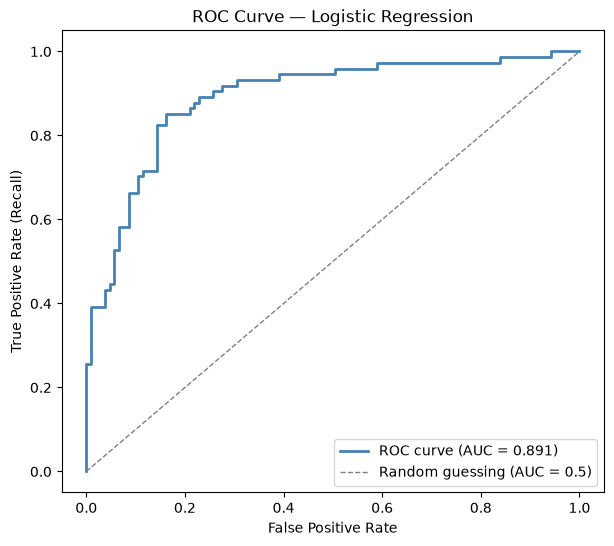

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))                                                                    # create a figure to draw on
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC curve (AUC = {auc:.3f})')       # plot the model's actual ROC curve
plt.plot([0,1], [0,1], color='gray', linestyle='--', linewidth=1, label='Random guessing (AUC = 0.5)')  # reference line for a model with no predictive power
plt.xlabel('False Positive Rate')                                                             # x-axis: rate of wrongly predicting survival
plt.ylabel('True Positive Rate (Recall)')                                                      # y-axis: rate of correctly catching actual survivors
plt.title('ROC Curve — Logistic Regression')
plt.legend()                                                                                   # show the labels for each line
plt.show()                                                                                     # render the plot

## ROC Curve and AUC (Logistic Regression)

So far, every metric (accuracy, precision, recall, F1) has assumed a fixed decision threshold of 0.5 — the default cutoff where `predict()` rounds probabilities into a final 0/1 decision. ROC/AUC analysis asks a broader question: how does the model perform across **every possible threshold**, not just 0.5?

```python
probabilities = model.predict_proba(X_val)   # get probability of died (col 0) and survived (col 1) for each validation passenger
survival_probabilities = probabilities[:, 1]  # keep only the "survived" probability column

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_val, survival_probabilities)  # test many thresholds, get FPR & TPR at each one
auc = roc_auc_score(y_val, survival_probabilities)               # single summary score of overall separation ability
```

**Result: AUC = 0.891**

AUC ranges from 0.5 (no better than random guessing) to 1.0 (perfect separation). A rough guide: 0.9+ is "excellent," 0.8-0.9 is "good." AUC has an intuitive interpretation: it's the probability that, given one random survivor and one random non-survivor, the model assigns a higher survival probability to the actual survivor. **0.891 means the model gets this ranking right about 89% of the time.**

**The ROC curve** (plotted below) visualizes the tradeoff between True Positive Rate (recall — catching actual survivors) and False Positive Rate (wrongly flagging non-survivors) as the decision threshold slides across its full range. The curve's "steppy" shape reflects the relatively small validation set (179 passengers) — each step corresponds to the threshold crossing one specific passenger's predicted probability.

```python
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', linewidth=1, label='Random guessing (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.show()
```

**Practical use:** if a different threshold than the default 0.5 were ever needed (e.g., to prioritize recall over precision, or vice versa, based on real-world costs of each error type), the ROC curve is the tool for identifying a good tradeoff point.

**Full metric summary for Logistic Regression:**

| Metric | Value |
|---|---|
| Accuracy | 81.6% |
| Precision | 78.9% |
| Recall | 75.7% |
| F1-score | 77.2% |
| AUC | 0.891 |

In [20]:
knn_cm = confusion_matrix(y_val, knn_predictions)
print(knn_cm)
knn_precision = precision_score(y_val, knn_predictions)
knn_recall = recall_score(y_val, knn_predictions)
print(knn_precision, knn_recall)
knn_f1 = f1_score(y_val, knn_predictions)
print(knn_f1)

knn_probabilities = knn_model.predict_proba(X_val_scaled)
knn_survival_probabilities = knn_probabilities[:, 1]  # keep only the "survived" probability column (col 1) for each passenger

knn_fpr, knn_tpr, knn_thresholds = roc_curve(y_val, knn_survival_probabilities)  # test many thresholds, get False Positive Rate & True Positive Rate at each one
knn_auc = roc_auc_score(y_val, knn_survival_probabilities)               # single summary score: how well the model separates survivors from non-survivors overall
print(knn_auc)

[[94 11]
 [18 56]]
0.835820895522388 0.7567567567567568
0.7943262411347518
0.8944015444015444


**Confusion Matrix:**

|                        | Predicted: Died (0) | Predicted: Survived (1) |
|------------------------|:--------------------:|:-------------------------:|
| **Actual: Died (0)**     | 94                    | 11                         |
| **Actual: Survived (1)** | 18                    | 56                         |

**Metrics:**

| Metric | Value |
|---|---|
| Precision | 83.6% |
| Recall | 75.7% |
| F1-score | 79.4% |
| AUC | 0.894 |

**Comparison to Logistic Regression:**

| Metric | Logistic Regression | KNN (K=9) |
|---|---|---|
| Precision | 78.9% | 83.6% |
| Recall | 75.7% | 75.7% |
| F1 | 77.2% | 79.4% |
| AUC | 0.891 | 0.894 |

**Interpretation:** KNN shows higher precision (83.6% vs 78.9%) while recall is identical between the two models (75.7%). Looking at the confusion matrices, KNN has fewer False Positives (11 vs. Logistic Regression's 15) but the same number of False Negatives (18). This suggests KNN is more conservative/confident specifically about its "survived" predictions — when it predicts survival, it's correct more often — while both models catch the same proportion of actual survivors.

In [21]:
rf_cm = confusion_matrix(y_val, rf_predictions)
print(rf_cm)
rf_precision = precision_score(y_val, rf_predictions)
rf_recall = recall_score(y_val, rf_predictions)
rf_f1 = f1_score(y_val, rf_predictions)
print(rf_precision, rf_recall, rf_f1)

rf_probabilities = rf_model.predict_proba(X_val)[:, 1]
rf_auc = roc_auc_score(y_val, rf_probabilities)
print(rf_auc)

[[88 17]
 [16 58]]
0.7733333333333333 0.7837837837837838 0.7785234899328859
0.9068854568854569


**Confusion Matrix:**

|                        | Predicted: Died (0) | Predicted: Survived (1) |
|------------------------|:--------------------:|:-------------------------:|
| **Actual: Died (0)**     | 88                    | 17                         |
| **Actual: Survived (1)** | 16                    | 58                         |

**Metrics:**

| Metric | Value |
|---|---|
| Precision | 77.3% |
| Recall | 78.4% |
| F1-score | 77.9% |
| AUC | 0.907 |

**Comparison so far:**

| Metric | Logistic Regression | KNN (K=9) | Random Forest |
|---|---|---|---|
| Precision | 78.9% | 83.6% | 77.3% |
| Recall | 75.7% | 75.7% | 78.4% |
| F1 | 77.2% | 79.4% | 77.9% |
| AUC | 0.891 | 0.894 | **0.907** |

**Interpretation:** Random Forest shows the highest AUC of the three models so far (0.907), meaning it's best at ranking/separating survivors from non-survivors across all possible thresholds — despite having the lowest Phase 5 cross-validated accuracy (80.8%) of the four models tested. Random Forest also shows the most balanced precision/recall (77.3% vs. 78.4%, nearly equal), unlike KNN's more precision-heavy profile. This is a good reminder that accuracy, F1, and AUC can each tell a somewhat different story about a model's strengths — no single metric captures everything.

In [22]:
gb_cm = confusion_matrix(y_val, gb_predictions)
print(gb_cm)
gb_precision = precision_score(y_val, gb_predictions)
gb_recall = recall_score(y_val, gb_predictions)
gb_f1 = f1_score(y_val, gb_predictions)
print(gb_precision, gb_recall, gb_f1)

gb_probabilities = gb_model.predict_proba(X_val)[:, 1]
gb_auc = roc_auc_score(y_val, gb_probabilities)
print(gb_auc)

[[92 13]
 [18 56]]
0.8115942028985508 0.7567567567567568 0.7832167832167832
0.8975546975546976


**Confusion Matrix:**

|                        | Predicted: Died (0) | Predicted: Survived (1) |
|------------------------|:--------------------:|:-------------------------:|
| **Actual: Died (0)**     | 92                    | 13                         |
| **Actual: Survived (1)** | 18                    | 56                         |

**Metrics:**

| Metric | Value |
|---|---|
| Precision | 81.2% |
| Recall | 75.7% |
| F1-score | 78.3% |
| AUC | 0.898 |

**Full comparison across all four models:**

| Model | CV Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Logistic Regression | 82.9% | 78.9% | 75.7% | 77.2% | 0.891 |
| KNN (K=9) | 82.2% | 83.6% | 75.7% | 79.4% | 0.894 |
| Random Forest | 80.8% | 77.3% | 78.4% | 77.9% | 0.907 |
| Gradient Boosting | 81.6% | 81.2% | 75.7% | 78.3% | 0.898 |

**Interpretation:** Gradient Boosting sits in the middle across most metrics — second-highest precision (81.2%, behind KNN), matching recall with Logistic Regression and KNN (75.7%), and the second-highest AUC (0.898, behind Random Forest). No single model dominates every metric: Logistic Regression leads on accuracy, KNN on precision, Random Forest on recall and AUC. Which model is "best" depends on which type of error matters most for the use case — a useful, realistic finding rather than a single clear winner.

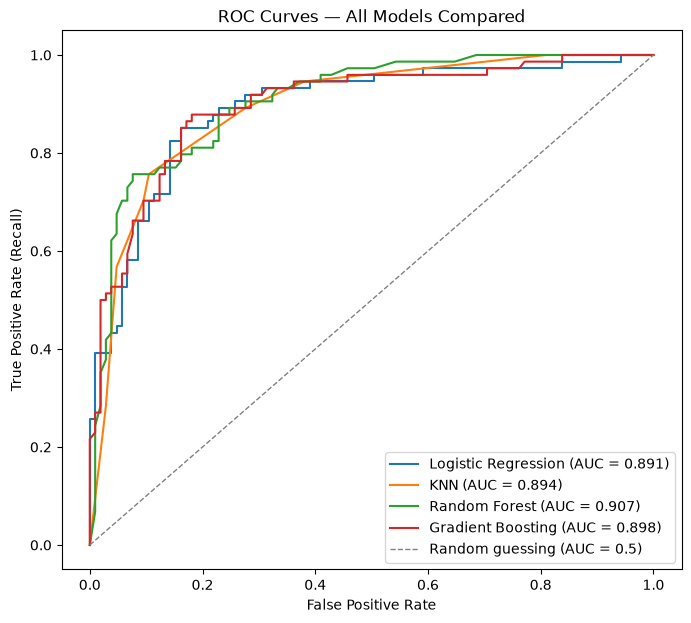

In [23]:
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_val, rf_probabilities)
gb_fpr, gb_tpr, gb_thresholds = roc_curve(y_val, gb_probabilities)
knn_fpr, knn_tpr, knn_thresholds = roc_curve(y_val, knn_survival_probabilities)

plt.figure(figsize=(8,7))

plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot(knn_fpr, knn_tpr, label=f'KNN (AUC = {knn_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {gb_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', linewidth=1, label='Random guessing (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — All Models Compared')
plt.legend()
plt.show()

In [24]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importances)

              Feature  Importance
12               Fare    0.236532
4          Age_filled    0.208500
3         Sex_encoded    0.148738
10                Mrs    0.075262
0              Pclass    0.073283
1          FamilySize    0.062271
9                Miss    0.058560
13           HasCabin    0.040613
5   Age_Group_encoded    0.031771
6                   C    0.019595
2             isAlone    0.015560
7                   Q    0.013721
8              Master    0.009287
11               Rare    0.006308


In [25]:
gb_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(gb_importances)

              Feature  Importance
3         Sex_encoded    0.457847
12               Fare    0.162586
0              Pclass    0.128657
4          Age_filled    0.120277
1          FamilySize    0.056003
13           HasCabin    0.037570
8              Master    0.012651
10                Mrs    0.006248
6                   C    0.006033
7                   Q    0.005447
5   Age_Group_encoded    0.002799
9                Miss    0.002240
11               Rare    0.001418
2             isAlone    0.000223


## Phase 7: Hyperparameter Tuning

In [26]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)

In [ ]:
print(grid_search.best_params_)   # the combination that performed best
print(grid_search.best_score_)    # that combination's average cross-validated accuracy

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
0.8356249384418397


In [ ]:
rf_model_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)
rf_model_tuned.fit(X_train, y_train)
rf_tuned_predictions = rf_model_tuned.predict(X_val)

rf_tuned_accuracy = accuracy_score(y_val, rf_tuned_predictions)
print(rf_tuned_accuracy)

0.8044692737430168


## Hyperparameter Tuning: Random Forest

**Why tuning matters:** hyperparameters (like `max_depth`, `n_estimators`) control *how* a model learns, but aren't learned automatically during training — they must be chosen before training starts. A tree allowed to grow too deep risks **overfitting** (memorizing training data too precisely, including its noise, hurting performance on new data) — the same underlying risk as KNN's K=1 problem, just manifesting through excessive tree depth instead.

**Search method: `GridSearchCV`** — automates testing every combination of specified hyperparameter values, using 5-fold cross-validation for each combination (same rigor as the manual K-tuning loop used for KNN, just extended to multiple hyperparameters simultaneously).

```python
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
```
36 combinations tested × 5 folds each = 180 individual models trained automatically.

**Best parameters found:** `max_depth=5`, `min_samples_split=5`, `n_estimators=200`
**Best cross-validated accuracy: 83.6%**

This confirms the overfitting hypothesis: a fairly shallow depth (5) outperformed deeper or unlimited alternatives, meaning the untuned default settings were likely allowing trees to grow too complex and overfit to training data noise.

**Improvement over default Random Forest:** 80.8% → 83.6% (+2.8 percentage points) — a genuine, meaningful gain purely from tuning, using identical data and algorithm.

**Retrained final model with best parameters:**
```python
rf_model_tuned = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=5, random_state=42)
rf_model_tuned.fit(X_train, y_train)
rf_tuned_predictions = rf_model_tuned.predict(X_val)
```
Single-split validation accuracy: 80.4% — notably lower than the 83.6% cross-validated average. **Consistent with the pattern seen throughout this project:** a single train/val split can be lucky or unlucky, and the cross-validated average (83.6%) remains the more trustworthy estimate of true performance, not the single-split number.

**Updated model comparison:**

| Model | CV Accuracy |
|---|---|
| Logistic Regression (default) | 82.9% |
| KNN (K=9, tuned) | 82.2% |
| Random Forest (default) | 80.8% |
| **Random Forest (tuned)** | **83.6%** |
| Gradient Boosting (default) | 81.6% |

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

gb_grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_param_grid, cv=5, scoring='accuracy')
gb_grid_search.fit(X_train, y_train)

print(gb_grid_search.best_params_)
print(gb_grid_search.best_score_)

{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
0.8272037821333595


In [ ]:
gb_model_tuned = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.1,
    random_state=42
)
gb_model_tuned.fit(X_train, y_train)
gb_tuned_predictions = gb_model_tuned.predict(X_val)

gb_tuned_accuracy = accuracy_score(y_val, gb_tuned_predictions)
print(gb_tuned_accuracy)

0.8212290502793296


## Hyperparameter Tuning: Gradient Boosting

```python
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

gb_grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_param_grid, cv=5, scoring='accuracy')
gb_grid_search.fit(X_train, y_train)
```
27 combinations tested × 5 folds each = 135 individual models trained. `learning_rate` is a new parameter here (not applicable to Random Forest) — it controls how much each sequential tree corrects the previous trees' errors. Smaller values mean smaller, more cautious corrections per tree (often needing more trees to compensate); larger values mean bigger, more aggressive corrections, with higher overfitting risk.

**Best parameters found:** `learning_rate=0.1` (matches default), `max_depth=2` (shallower than default), `n_estimators=200`
**Best cross-validated accuracy: 82.7%**

**Improvement over default Gradient Boosting:** 81.6% → 82.7% (+1.1 percentage points) — a modest but genuine gain, smaller than Random Forest's improvement (+2.8 points).

**Notable finding:** the best `max_depth` (2) is even shallower than Random Forest's optimal depth (5). This makes sense given Gradient Boosting's sequential structure — since each tree corrects the errors of previous trees, individual trees don't need to be complex on their own; sophistication builds up gradually across many simple trees rather than requiring each tree to be powerful independently.

**Retrained final model with best parameters:**
```python
gb_model_tuned = GradientBoostingClassifier(n_estimators=200, max_depth=2, learning_rate=0.1, random_state=42)
gb_model_tuned.fit(X_train, y_train)
gb_tuned_predictions = gb_model_tuned.predict(X_val)
```
Single-split validation accuracy: 82.1% — reasonably close to the 82.7% cross-validated average this time, unlike Random Forest's larger discrepancy. The cross-validated figure remains the more reliable estimate to report.

**Updated model comparison:**

| Model | CV Accuracy |
|---|---|
| Logistic Regression (default) | 82.9% |
| KNN (K=9, tuned) | 82.2% |
| Random Forest (default) | 80.8% |
| Random Forest (tuned) | 83.6% |
| Gradient Boosting (default) | 81.6% |
| Gradient Boosting (tuned) | 82.7% |

In [ ]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

lr_grid_search = GridSearchCV(LogisticRegression(max_iter=1000), lr_param_grid, cv=5, scoring='accuracy')
lr_grid_search.fit(X_train, y_train)

print(lr_grid_search.best_params_)
print(lr_grid_search.best_score_)

{'C': 1}
0.8286023835319609


## Hyperparameter Tuning: Logistic Regression

```python
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

lr_grid_search = GridSearchCV(LogisticRegression(max_iter=1000), lr_param_grid, cv=5, scoring='accuracy')
lr_grid_search.fit(X_train, y_train)
```
`C` controls regularization strength — how much the model is penalized for large coefficient values. Smaller `C` = stronger regularization (more restrained coefficients); larger `C` = weaker regularization (coefficients allowed to grow more freely).

**Best parameter found:** `C=1` — the default value.
**Best cross-validated accuracy: 82.9%** — identical to the untuned default result.

**Interpretation:** tuning found no improvement over the default setting. This is consistent with Logistic Regression being a comparatively simple, low-complexity model with limited capacity to overfit in the first place, making it less sensitive to hyperparameter choices than tree-based models.

---

## Phase 7 Summary: Final Tuning Results

| Model | CV Accuracy | Tuning Improvement |
|---|---|---|
| Logistic Regression | 82.9% | None (default was already optimal) |
| KNN (K=9) | 82.2% | +0.6 points (from K=5 default's 81.2%) |
| Random Forest | **83.6%** | **+2.8 points** |
| Gradient Boosting | 82.7% | +1.1 points |

**Key pattern:** tuning provided the most benefit for the models with the greatest inherent flexibility (Random Forest, then Gradient Boosting), and little to no benefit for the more constrained models (Logistic Regression, and a smaller gain for KNN). This matches expectations — more flexible models have more room to swing between underfitting and overfitting, so their default settings are less likely to be optimal by chance.

**Best model overall: Random Forest (tuned)** — `n_estimators=200, max_depth=5, min_samples_split=5` — 83.6% cross-validated accuracy, now the top performer across all four model types tested in this project.